In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [9]:
df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

df = df.dropna(subset=["Daily_Return"])

In [10]:
tsla = df[df["Ticker"] == "TSLA"][["Date", "Daily_Return"]].copy()

tsla.set_index("Date", inplace=True)

tsla = tsla.asfreq("B")  # business days
tsla = tsla.fillna(0)    # simple handling for gaps

print(tsla.head())

            Daily_Return
Date                    
2015-01-05     -0.042041
2015-01-06      0.005664
2015-01-07     -0.001562
2015-01-08     -0.001564
2015-01-09     -0.018802


TRAIN / TEST SPLIT

In [11]:
train_size = int(len(tsla) * 0.8)

train = tsla.iloc[:train_size]
test = tsla.iloc[train_size:]

print(len(train), len(test))

2396 600


FIT ARIMA MODEL

In [12]:
model = ARIMA(train["Daily_Return"], order=(5, 0, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Daily_Return   No. Observations:                 2396
Model:                 ARIMA(5, 0, 1)   Log Likelihood                4648.559
Date:                Sun, 05 Jul 2026   AIC                          -9281.119
Time:                        12:33:35   BIC                          -9234.866
Sample:                    01-05-2015   HQIC                         -9264.291
                         - 03-11-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      2.199      0.028       0.000       0.003
ar.L1         -0.0028      0.933     -0.003      0.998      -1.831       1.826
ar.L2          0.0166      0.017      0.996      0.3

FORECAST

In [13]:
forecast = model_fit.forecast(steps=len(test))

forecast = pd.Series(forecast, index=test.index)

VISUALIZE RESULTS

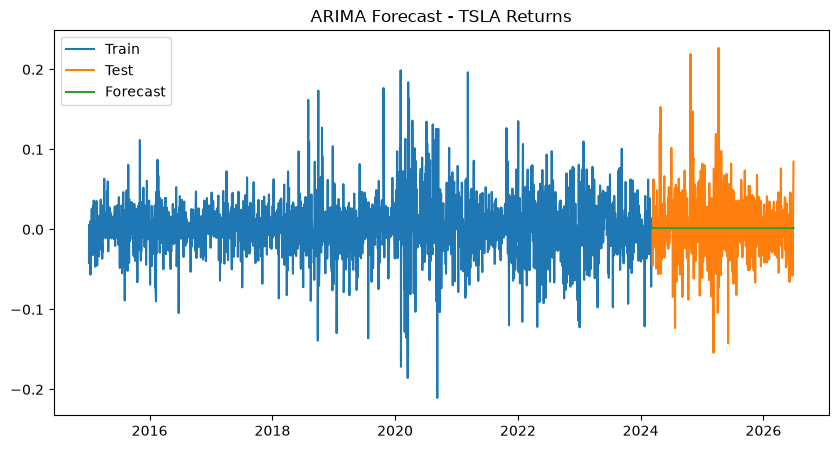

In [14]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train["Daily_Return"], label="Train")
plt.plot(test.index, test["Daily_Return"], label="Test")
plt.plot(forecast.index, forecast, label="Forecast")

plt.title("ARIMA Forecast - TSLA Returns")
plt.legend()
plt.show()

MODEL EVALUATION

In [15]:
rmse = np.sqrt(mean_squared_error(test["Daily_Return"], forecast))
print("RMSE:", rmse)

RMSE: 0.037474071221816625


ARIMA Results Interpretation
Model captures short-term autocorrelation
TSLA returns are noisy → weak predictability
Forecast closely resembles mean-reverting noise
RMSE reflects high volatility nature of equity returns